
**Introduction to the Optimization Problem**
========================================

The goal of this project is to solve a constrained convex optimization problem. As described in the reference theory, we consider problems of the general form:

$$
\begin{aligned}
&\min_{x \in D} \; f(x) \\
&\text{where } f: \mathbb{R}^n \to \mathbb{R} \text{ is convex and differentiable, and } D \subset \mathbb{R}^n \text{ is a compact, convex set.}
\end{aligned}
$$

Application: Markowitz Portfolio Optimization
---------------------------------------------
In our specific case, we apply this framework to the  Markowitz portfolio optimization problem. The problem is:


$$
\min_{x \in \mathbb{R}^n}\;\ \gamma x^T\Sigma x -\bar r^T x
$$




This objective functions must follows these constraints:

$$
 \sum_{i=1}^n x_i = B=1,
$$

$$
x_i \geq 0 \quad \
$$

where the sum $x_i$ must be equal to the Budget( we set for simplicity equal to 1)

## Parameters of the function

- $\gamma$: the risk-aversion parameter must be > 0 .
- $ \Sigma$: the covariance matrix of asset returns.
- $\bar{r}$ : the vector of expected (mean) returns.
- $x = (x_1, \dots, x_n)^T$: the decision vector where  $xi$ representing the quantity of money invested on the invested in the *i-th* asset.
- overall portfolio expected return:  $$\bar r^T x $$.
- **Overall Portfolio Variance**:    
   $$x^T \Sigma\,x$$
- $\gamma \cdot x^\top\Sigma x$: total portfolio variance (risk) and weight it by  risk‑aversion parameter.



## Goal:
The goal is minimize the objective function that will bring to a consequent maximization on of the expected return  that minimize the variance ( i.e the $\gamma$ that represents risk adversion )




In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from time import time
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from tabulate import tabulate

In [ ]:
try:
    from google.colab import drive
    IN_COLAB=True
except ImportError:
    IN_COLAB=False

#paths according to env
if IN_COLAB:
    print("loading colab environment")

    os.makedirs('./opt_project', exist_ok=True)
    drive.mount('./opt_project/dataset')
    #colab base path
    base_path='./opt_project/dataset/MyDrive/opt_project/dataset/daily industry porfolios/'

    #colab paths
    dataset_paths={
        "12 Industry Portfolios": os.path.join(base_path, "12_Industry_Portfolios_Daily.csv"),
        "17 Portfolios": os.path.join(base_path, "17_Industry_Portfolios_Daily.csv"),
        "49 Industry Portfolios": os.path.join(base_path, "49_Industry_Portfolios_Daily.csv")}
else:
    print("Local environment detected. Using local paths.")
    #local base path
    base_path="/Users/martafeltrin/Desktop/opt project/dataset/daily industry porfolios/"
             #"C:/Users/pietr/Downloads/dataset_project/daily industry porfolios"
    #local env
    dataset_paths={
        "12 Industry Portfolios": os.path.join(base_path, "12_Industry_Portfolios_Daily.csv"),
        "17 Portfolios": os.path.join(base_path, "17_Industry_Portfolios_Daily.csv"),
        "49 Industry Portfolios": os.path.join(base_path, "49_Industry_Portfolios_Daily.csv")
    }

Local environment detected. Using local paths.


In [ ]:
conv_tol=1e-6
gamma=1
max_iter=100
np.random.seed(72)

## **Helper functions**



## Objective Function and Gradient


The  function to be minimized here is:

$$f(x) = \gamma x^T \Sigma x - \bar{r}^T x$$

The gradient of this specific objective function with respect to $x$ is:

$$ \nabla f(x) = 2\gamma \Sigma x - \bar{r} $$

This gradient is essential for algorithms that rely on first-order information to find the minimum.



In [ ]:
def obj_fun(x, gamma, exp_returns, cov_matrix):  #compute the objective function
    return gamma * x.T @ cov_matrix @ x - exp_returns.T @ x

def obj_fgradient(x, gamma, exp_returns, cov_matrix): #compute the objective function gradient
    return 2 * gamma * cov_matrix @ x - exp_returns

### Linear Minimization Oracle (LMO)

In the Frank-Wolfe algorithm, the **Linear Minimization Oracle (LMO)** is a function that replaces the projection step used in projected gradient methods, so makes Frank-Wolfe a **projection-free** algorithm and Naturally promotes **sparse** or **low-rank** solutions..

At iteration *k*, given the current point $x^{(k)}$ and gradient $\nabla f(x^{(k)})$, the LMO solves:

$$s^{(k)} = \arg\min_{s \in \mathcal{D}} \langle \nabla f(x^{(k)}), s \rangle$$

This finds the atom (or extreme point) in the domain $\mathcal{D}$ that most decreases the linear approximation of the objective.

* Provides the **descent direction**:
    $$d^{(k)} = s^{(k)} - x^{(k)}$$
* Used instead of projection: avoids expensive computations.
* Enables updates of the form:
    $$x^{(k+1)} = (1 - \gamma_k)x^{(k)} + \gamma_k s^{(k)}$$



In [ ]:
def LMO(grad):
    idx=np.argmin(grad)
    s=np.zeros_like(grad)
    s[idx]=1.0
    return s

### Exact line search

$$ \alpha_k = \min_{\alpha \in [0, \alpha_k^{\max}]} \arg \min \varphi(\alpha) \quad \text{with } \varphi(\alpha) := f(x_k + \alpha d_k), $$

In [ ]:
def exact_line_search(direction, grad, gamma, cov_matrix, step_limit=1.0):
  gap= -(direction @grad)
  denom= 2 * gamma *(direction.T @ cov_matrix @ direction)

  if denom<1e-10:
    alpha=step_limit
  else:
    alpha=gap/denom

  alpha_final= min(max(0, alpha), step_limit) #guarantees alpha belongs between 0 and alpha max
  return alpha_final


### Visualize portfolio


In [ ]:
def visualize_portfolio_bar(weights, asset_names=None, chart_title=''):
    """
    To visualize bar plots for the best weight allocation for the portfolios
    """

    #converts in percentages
    w = np.array(weights) * 100
    names = np.array(asset_names)

    fig = go.Figure()
    colors = px.colors.qualitative.Vivid
    thresh = 0.1

    #mask for significant assets
    sig = w >= thresh
    sig_names = names[sig]
    sig_w = w[sig]

    #significant assets legend
    for i, (n, pct) in enumerate(zip(sig_names, sig_w)):
        fig.add_trace(go.Bar(
            x=[n],
            y=[pct],
            name=f"{n} ({pct:.2f}%)",
            marker_color=colors[i % len(colors)],
            text=f"{pct:.2f}%",
            textposition='auto',
            showlegend=True
        ))

    #find non significant assets and build up legend
    other_mask = ~sig #we takes the non significant assets
    if other_mask.sum() > 0:
        other_pct_sum = w[other_mask].sum() #sum all "other" percentages

        fig.add_trace(go.Bar(
            x=['Other'],
            y=[other_pct_sum],
            name="Other",
            marker_color='lightgrey',
            text=f"{other_pct_sum:.2f}%",
            textposition='auto',
            showlegend=True
        ))

    #layout
    fig.update_layout(
        title=chart_title,
        title_x=0.5,
        xaxis_title="Asset",
        yaxis_title="Weight (%)",
        barmode='group',
        bargap=0.2
    )
    #ensure x-axis order matches the original asset_names for consistency
    fig.update_xaxes(categoryorder='array', categoryarray=asset_names)
    fig.show()

# **Frank-Wolfe Algorithm**

The Frank-Wolfe (FW) optimization algorithm, also known as the **conditional gradient method**, is an iterative procedure for solving constrained convex optimization problems of the form:

$$
\min_{x \in \mathcal{D}} f(x)
$$

Here, the objective function $f$ is assumed to be **convex and continuously differentiable**, and the domain $\mathcal{D}$ is a **compact convex subset**.

## Algorithm Steps:

1.  **Find Descent Direction (LMO):** At each iteration $k$, compute a new candidate point $s^{(k)}$ by minimizing the linear approximation of the objective over the domain $\mathcal{D}$, using the current gradient $\nabla f(x^{(k)})$ :
$s^{(k)} := \arg\min_{s \in \mathcal{D}} \langle \nabla f(x^{(k)}), s \rangle$
2.  **Update Solution:** Calculate the next iterate $x^{(k+1)}$ as a convex combination of the current point $x^{(k)}$ and the candidate point $s^k$ :
$x^{(k+1)} := (1 - \gamma_k)x^{(k)} + \gamma_k s^{(k)}$, for $\gamma_k := \frac{2}{k+2}$

## Elements:

* **$x^{(k)}$:** The current solution (portfolio weights) at iteration $k$.
* **$f(x)$:** The convex and differentiable objective function to minimize.
* **$\nabla f(x^{(k)})$:** The gradient of the objective function at the current point, indicating the direction of steepest ascent.
* **$\mathcal{D}$:** The feasible domain (e.g., the probability simplex for portfolio weights).
* **$s^{(k)}$:** The new candidate point (or "atom") found by the LMO. It's an extreme point of the domain $\mathcal{D}$.
* **$\gamma_k$:** The step size (or learning rate) for the current iteration. A common choice is $\gamma_k = \frac{2}{k+2}$, which ensures theoretical convergence by gradually decreasing the step size over iterations.



## Convergence:

The iterates of the Frank-Wolfe algorithm satisfy $f(x^{(k)}) - f(x^*) \le O(\frac{1}{k})$, where $x^*$ is an optimal solution.


In [ ]:
def frank_wolfe(obj_function, obj_fgradient, LMO, start_point, step_rule, gamma, cov_matrix, exp_returns, max_iters=max_iter, tolerance=conv_tol):
    """
    solves a convex optimization problem using the Frank-Wolfe algorithm.
    """
    x=start_point.copy()

    #lists for saving history of objective and gap
    obj_history=[]
    gap_history=[]
    t0=time()

    for k in range(max_iters):
        grad=obj_fgradient(x, gamma, exp_returns, cov_matrix)

        obj_history.append(obj_function(x, gamma, exp_returns, cov_matrix))
        s=LMO(grad)
        direction= s - x
        gap= -(direction @ grad)
        gap_history.append(gap)

        if gap <= tolerance:
            break

        if step_rule == 'diminishing':
            alpha = 2 / (k + 2)
        else: #step_rule == 'exact line':
            alpha=exact_line_search(direction, grad, gamma, cov_matrix)

        x = x + alpha * direction

    cpu_time=time() - t0
    final_obj= obj_fun( x, gamma, exp_returns, cov_matrix)
    final_grad=obj_fgradient(x, gamma, exp_returns, cov_matrix)
    final_s=LMO(final_grad)
    final_gap= -((final_s - x) @ final_grad)

    obj_history.append(final_obj)
    gap_history.append(final_gap)

    return x, obj_history, gap_history, k + 1, cpu_time

## **Away-Steps Frank-Wolfe (AFW)**


The standard Frank-Wolfe algorithm can zig-zag near the boundary of the feasible region, which slows convergence. The **Away-Steps Frank-Wolfe (AFW)** variant allows the algorithm not only to move toward better vertices but also to move **away** from previously selected (bad) ones. This improves convergence, especially when the solution lies on the boundary.

At each iteration, AFW considers **two directions**:

* **FW direction**: toward the best vertex $s_t$ minimizing the linearized objective.
  $$ d_t^{FW} = s_t - x^{(t)} $$

* **Away direction**: away from the worst active vertex $v_t$ currently used in the convex combination.
  $$ d_t^{A} = x^{(t)} - v_t $$

The algorithm chooses the direction that gives the most decrease in the objective.

1.  **Initialize** at a vertex $x^{(0)}$, with active set $S^{(0)}$.
2.  For each iteration:
    - Compute FW direction: minimize linear approximation.
    - Compute Away direction: maximize gradient over current atoms.
    - Compare both directions:
        - If FW direction gives more decrease → take FW step.
        - Else → take Away step (removing weight from bad vertex).
    - Line search along chosen direction.
    - Update the iterate and active set.
3. Stopping criterion:
- The algorithm stops when the **FW duality gap** is below a threshold $\varepsilon$:
  $$g_t^{FW} = \langle -\nabla f(x^{(t)}), d_t^{FW} \rangle \leq \varepsilon$$  This ensures that the current point is close to optimal.

## Convergence

AFW achieves **linear convergence** under standard assumptions (strong convexity, polytope domain), unlike standard FW which is only sublinear.

In [ ]:
def away_steps_fw(obj_function, obj_fgradient, LMO, start_idx, num_asset, gamma, cov_matrix, exp_returns, max_iters=max_iter, tolerance=conv_tol):
    """
    Solves a convex optimization problem using the Away-Steps Frank-Wolfe algorithm.
    """

    #defining a random vertex from where start
    n=num_asset
    x=np.zeros(n)
    x[start_idx]=1.0
    weights={start_idx: 1.0} #active set as dictionary with vertex:weight

    obj_history=[]
    gap_history=[]
    t0=time()

    for k in range(max_iters):
        grad=obj_fgradient(x, gamma, exp_returns, cov_matrix)
        obj_history.append(obj_function(x, gamma, exp_returns, cov_matrix))

        #fw vertex
        s_vec=LMO(grad)
        s_idx=np.argmax(s_vec) #to find the index of s

        #away vertex
        active_indices=list(weights.keys()) #the list of active indices
        v_idx=active_indices[np.argmax(grad[active_indices])]
        v_vec=np.eye(n)[v_idx]

        #stopping condition
        fw_gap= -np.dot(grad, s_vec - x)
        gap_history.append(fw_gap)
        if fw_gap <= tolerance:
            break

        #direction
        away_gap= -(grad@( x - v_vec))
        if fw_gap >= away_gap:
            #choose FW direction
            direction=s_vec - x
            alpha_max=1.0
            is_fw_step=True
        else:
            #choose away direction
            direction=x - v_vec
            #handle case where weight is 1 to avoid division by zero
            if abs(weights[v_idx] - 1.0) < 1e-10:
                alpha_max=1.0
            else:
                alpha_max=weights[v_idx] / (1.0 - weights[v_idx])
                #gamma_max =x[np.argmax(v)]/(1-x[np.argmax(v)])
            is_fw_step = False

        #stepsize
        alpha=exact_line_search(direction, grad, gamma, cov_matrix, step_limit=alpha_max)

        #update x
        x= x+alpha*direction

        #update active set
        if is_fw_step:
            for idx in list(weights.keys()):
                weights[idx] = (1 - alpha) * weights[idx] #if alpha=1, S(t+1)={s_t}
                weights[s_idx] = (1 - alpha) * weights.get(s_idx, 0.0) + alpha  #if alpha<1, S(t) ∪ {s_t}
        else:
            #away step
            for idx in list(weights.keys()): #iterate
                if idx == v_idx: #if idx==idx of the away vertex
                    weights[idx] = (1 + alpha) * weights[idx] - alpha #if alpha=alpha_max, S(t)\{v_t}
                else:
                    weights[idx] = (1 + alpha) * weights[idx] #if alpha<alpha_max, S(t+1)=S(t)

        #clean up weights
        #drop step
        if weights.get(v_idx, 0) < 1e-9:
            del weights[v_idx] #remove vertex v_t from active set

    cpu_time = time() - t0
    return x, obj_history, gap_history, k + 1, cpu_time

## **Pairwise Frank-Wolfe (PFW)**

The **Pairwise Frank-Wolfe (PFW)** algorithm is a variant of Frank-Wolfe that improves convergence by **redistributing weight between two atoms only** in each iteration. The pairwise direction is central to proving **global linear convergence rates** for Away-steps FW, Fully Corrective FW, and Wolfe’s min-norm-point algorithm.

Instead of shrinking all weights like classical Frank-Wolfe, PFW performs a  swap between two atoms:

- **Decrease** weight on the current worst atom $v_t$ (the away direction),
- **Increase** weight on the best new atom $s_t$ (the Frank-Wolfe direction),
- **All other weights stay unchanged**.

This gives the update:
$
\alpha_{v_t}^{(t+1)} = \alpha_{v_t}^{(t)} - \gamma, \quad
\alpha_{s_t}^{(t+1)} = \alpha_{s_t}^{(t)} + \gamma
$

where $\gamma \le \alpha_{v_t}^{(t)}$ ensures feasibility.

## Characteristics

- The update direction is:
    $$ d_t^{\text{PFW}} = s_t - v_t $$
- This approach **maintains sparsity** more tightly than standard or away-steps FW.
- It enables sharper convergence in polytopal domains, especially when the solution is on a low-dimensional face.





In [ ]:
def pw_frank_wolfe(obj_function, obj_fgradient, LMO, start_idx, n, gamma, cov_matrix, exp_returns, max_iters=max_iter, tolerance=conv_tol):
    """
    Solves a convex optimization problem using the Away-Steps Frank-Wolfe algorithm.
    """

    x=np.zeros(n)
    x[start_idx]=1.0
    weights={start_idx: 1.0}

    obj_history=[]
    gap_history=[]
    t0=time()

    for k in range(max_iters):
        grad=obj_fgradient(x, gamma, exp_returns, cov_matrix)
        obj_history.append(obj_function(x, gamma, exp_returns, cov_matrix))

        #fw vertex
        s_vec=LMO(grad)
        s_idx=np.argmax(s_vec)

        #away vertex
        active_indices=list(weights.keys()) #the list of active indices
        v_idx=active_indices[np.argmax(grad[active_indices])]
        v_vec = np.zeros(n)
        v_vec[v_idx]=1

        #fw gap
        gap= -np.dot(grad, s_vec - x)
        gap_history.append(gap)

        #stopping condition
        if gap <= tolerance:
            break

        #direction
        direction=s_vec - v_vec

        #max step
        alpha_max=weights[v_idx]

        #step-size
        alpha=exact_line_search(direction, grad, gamma, cov_matrix,step_limit=alpha_max)

        x=x+alpha*direction

        #update weights
        weights[v_idx] -= alpha #remove weight from the 'bad' vertex
        weights[s_idx] = weights.get(s_idx, 0.0) + alpha #add weight to the s_t vertex
                                                         # .get: if vertex s is already in the active set get its weight, if not set its weight=0

        #if weight is too small, remove it from the list of active vertices
        if weights.get(v_idx, 0) < 1e-9:
            del weights[v_idx]

    cpu_time = time() - t0
    return x, obj_history, gap_history, k + 1, cpu_time

# Loading  data

In [ ]:
def load_fama_french_data(file_path):
    """
    Load and clean datasets
    """

    try:
        with open(file_path, 'r', encoding='latin1') as f:
          lines=f.readlines()

        start_line = None
        #loop to find the header row
        for i, line in enumerate(lines):
            #header: first non-empty line with commas
            if "Date" in line or "Unnamed: 0" in line or (',' in line and start_line is None):
                if line.count(',') > 2: #>2 columns
                    start_line = i
                    break

        if start_line is None:
            raise ValueError("Header row not found in the file.")

        #loop to find the end of the data block
        end_line = len(lines)
        for i in range(start_line + 1, len(lines)):
            line = lines[i].strip()
            #ends at the first blank line
            if not line:
                end_line = i
                break

        #calculate how many rows of data to read
        num_data_rows = end_line - start_line - 1

        #load the specific chunk of data with pandas
        df = pd.read_csv(file_path, skiprows=start_line, nrows=num_data_rows)

        df = df.rename(columns={df.columns[0]: 'Date'})
        df['Date'] = df['Date'].astype(str).str.strip()
        df = df.set_index('Date')
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
        df.replace([-99.99, -999], np.nan, inplace=True)
        na_count=df.isna().sum().sum()
        print("number of missing values :", na_count)
        df = df.apply(pd.to_numeric, errors='coerce')
        df.dropna(inplace=True)

        start_date = '2000-04-30'
        end_date = '2025-04-30'
        df = df.loc[start_date:end_date]

        print(f"-> Data filtered for period {start_date} to {end_date}. Remaining rows: {len(df)}")
        df = df / 100.0
        Sigma = df.cov().values
        r = df.mean().values
        asset_names = df.columns.tolist()

        print(f"Dataset '{file_path}' loaded. Found {len(r)} assets.")
        return Sigma, r, asset_names

    except Exception as e:
        print(f"ERROR while loading '{file_path}': {e}")
        return None, None, None


# **Running datasets on algorithms**

In [ ]:
all_results = {}

#load datasets
for name, path in dataset_paths.items():
    print(f"\n{'='*60}\n Running algorithms for: {name}\n{'='*60}")

    Sigma, r, asset_names = load_fama_french_data(path)
    if Sigma is None:
      continue

    #set random point
    num_asset=len(np.array(asset_names))
    rand_pos=np.random.randint(num_asset)

    all_results[name]= {'asset_names': asset_names, 'runs': {}}

    obj_func_s = lambda x: obj_fun(x, gamma, r, Sigma)
    grad_func_s = lambda x: obj_fgradient(x, gamma, r, Sigma)
    #-----------------------------------------------------------------------
    # 1. Frank-Wolfe classic (Diminishing)
    x0=np.zeros(num_asset)
    x0[rand_pos]= 1

    final_x, obj_hist, gap_hist, num_iters, cpu_time = frank_wolfe(
        obj_fun, obj_fgradient, LMO, x0, 'diminishing', gamma, Sigma, r)

    all_results[name]['runs']['FW Diminishing'] = {
        'final_x': final_x, 'gap_history': gap_hist, 'obj_history': obj_hist,
        'iterations': num_iters, 'cpu_time': cpu_time}
    #-----------------------------------------------------------------------
    # 2. Frank-Wolfe classic (Exact Line Search)
    final_x, obj_hist, gap_hist, num_iters, cpu_time = frank_wolfe(
        obj_fun, obj_fgradient, LMO, x0, "exact line", gamma, Sigma, r)

    all_results[name]['runs']['FW Line Search'] = {
        'final_x': final_x, 'gap_history': gap_hist, 'obj_history': obj_hist,
        'iterations': num_iters, 'cpu_time': cpu_time}
    #-----------------------------------------------------------------------
    # 3. Pairwise Frank-Wolfe
    final_x, obj_hist, gap_hist, num_iters, cpu_time = pw_frank_wolfe(
        obj_fun, obj_fgradient, LMO, rand_pos, num_asset, gamma, Sigma, r)

    all_results[name]['runs']['Pairwise FW'] = {
        'final_x': final_x, 'gap_history': gap_hist, 'obj_history': obj_hist,
        'iterations': num_iters, 'cpu_time': cpu_time}
    #-----------------------------------------------------------------------
    # 4. Away-Steps Frank-Wolfe
    final_x, obj_hist, gap_hist, num_iters, cpu_time = away_steps_fw(
        obj_fun, obj_fgradient, LMO, rand_pos, num_asset, gamma, Sigma, r)

    all_results[name]['runs']['Away-Steps FW'] = {
        'final_x': final_x, 'gap_history': gap_hist, 'obj_history': obj_hist,
        'iterations': num_iters, 'cpu_time': cpu_time}


 Running algorithms for: 12 Industry Portfolios
number of missing values : 0
-> Data filtered for period 2000-04-30 to 2025-04-30. Remaining rows: 6289
Dataset '/Users/martafeltrin/Desktop/opt project/dataset/daily industry porfolios/12_Industry_Portfolios_Daily.csv' loaded. Found 12 assets.

 Running algorithms for: 17 Portfolios
number of missing values : 0
-> Data filtered for period 2000-04-30 to 2025-04-30. Remaining rows: 6289
Dataset '/Users/martafeltrin/Desktop/opt project/dataset/daily industry porfolios/17_Industry_Portfolios_Daily.csv' loaded. Found 17 assets.

 Running algorithms for: 49 Industry Portfolios
number of missing values : 67250
-> Data filtered for period 2000-04-30 to 2025-04-30. Remaining rows: 6289
Dataset '/Users/martafeltrin/Desktop/opt project/dataset/daily industry porfolios/49_Industry_Portfolios_Daily.csv' loaded. Found 49 assets.


# **Comparisons**

In [ ]:
#performance table
print("\n" + "="*80)
print(" PERFORMANCE RESULTS ")
print("="*80)

table_data=[]
headers=["Dataset", "Algorithm", "Iterations", "Final Gap", "CPU Time (s)"]

for dataset_name, data in all_results.items():
    for algo_name, run_data in data['runs'].items():
        table_data.append([
            dataset_name,
            algo_name,
            run_data['iterations'],
            f"{run_data['gap_history'][-1]:.2e}",
            f"{run_data['cpu_time']:.4f}"
        ])
    if dataset_name != list(all_results.keys())[-1]:
        table_data.append(['---']*5)

#print the table
print(tabulate(table_data, headers=headers, tablefmt="fancy_grid"))


 PERFORMANCE RESULTS 
╒════════════════════════╤════════════════╤══════════════╤═════════════╤════════════════╕
│ Dataset                │ Algorithm      │ Iterations   │ Final Gap   │ CPU Time (s)   │
╞════════════════════════╪════════════════╪══════════════╪═════════════╪════════════════╡
│ 12 Industry Portfolios │ FW Diminishing │ 30           │ 3.96e-07    │ 0.0003         │
├────────────────────────┼────────────────┼──────────────┼─────────────┼────────────────┤
│ 12 Industry Portfolios │ FW Line Search │ 8            │ 2.89e-07    │ 0.0001         │
├────────────────────────┼────────────────┼──────────────┼─────────────┼────────────────┤
│ 12 Industry Portfolios │ Pairwise FW    │ 4            │ 6.31e-07    │ 0.0001         │
├────────────────────────┼────────────────┼──────────────┼─────────────┼────────────────┤
│ 12 Industry Portfolios │ Away-Steps FW  │ 9            │ 3.28e-07    │ 0.0002         │
├────────────────────────┼────────────────┼──────────────┼─────────────┼─────

# **Plotting**


--- PLOTTING CONVERGENCE GRAPHS ---


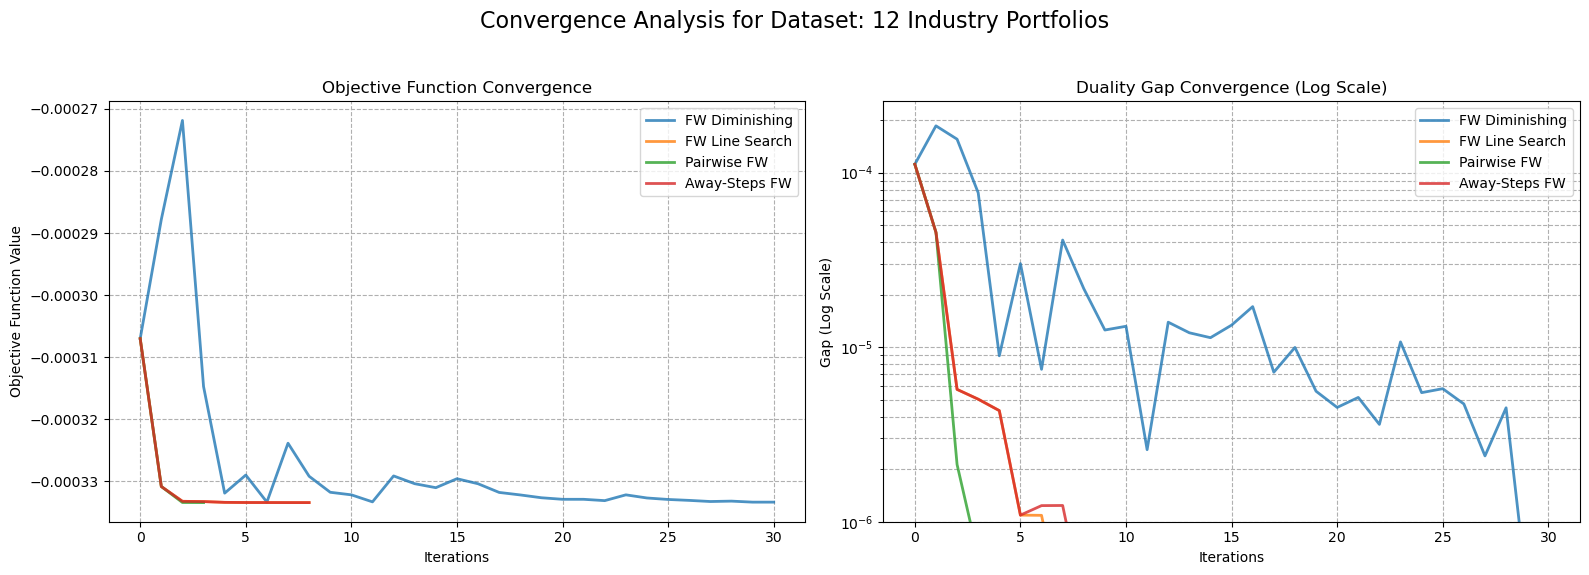

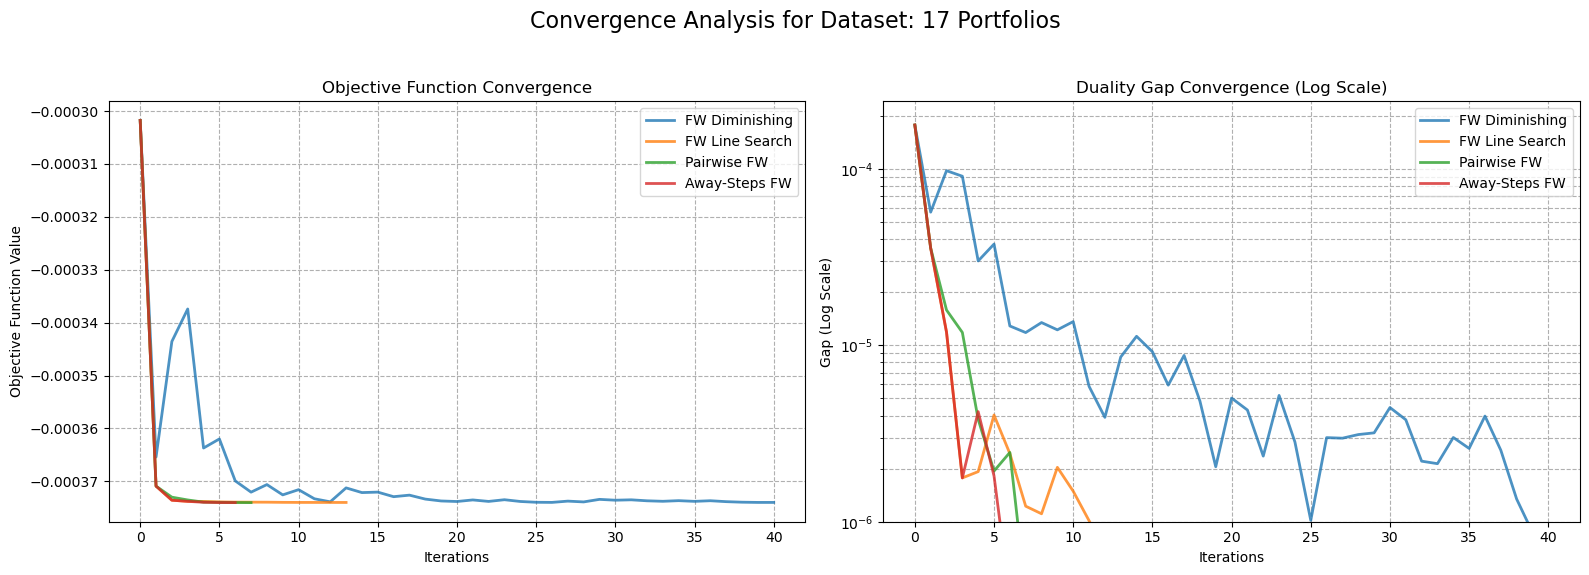

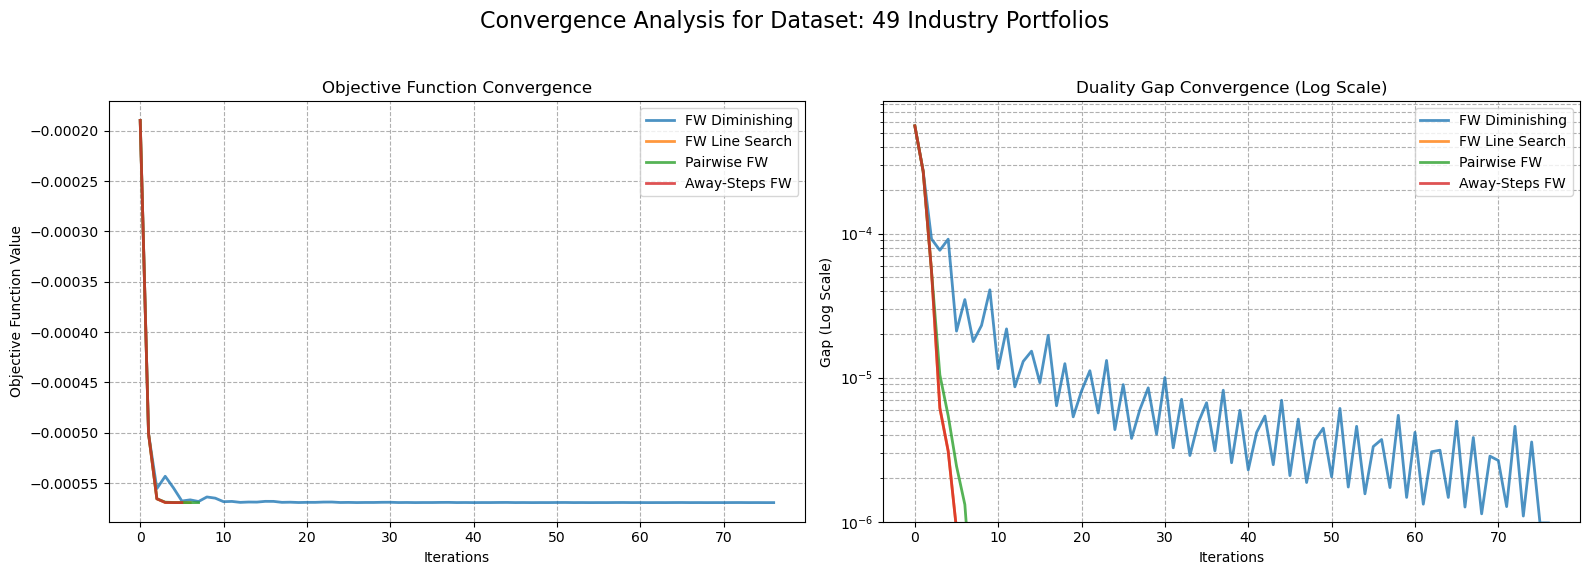

In [ ]:
# plot of different convergence gaps   ---
print("\n" + "="*80)
print("--- PLOTTING CONVERGENCE GRAPHS ---")
print("="*80)

pastel = px.colors.qualitative.Pastel

algorithm_colors = {
    "FW Diminishing": pastel[0],
    "FW Line Search": pastel[1],
    "Pairwise FW":    pastel[2],
    "Away-Steps FW":  pastel[3],
}

for dataset_name, data in all_results.items():

    # Create a figure with two subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Convergence Analysis for Dataset: {dataset_name}", fontsize=16)

    #loop through the results of this dataset
    for algo_name, run_data in data['runs'].items():
        # Matplotlib will automatically pick colors from the 'Pastel1' (or 'Pastel2') palette.

        #left Graph: Objective Function Value
        ax1.plot(run_data['obj_history'], label=algo_name, linewidth=2, alpha=0.8)

        #right graph: Duality Gap
        ax2.semilogy(run_data['gap_history'], label=algo_name, linewidth=2, alpha=0.8) #we do a log scale for the gap values on the y-axis

    #settings for left graph
    ax1.set_title("Objective Function Convergence")
    ax1.set_xlabel("Iterations")
    ax1.set_ylabel("Objective Function Value")
    ax1.legend()
    ax1.grid(True, which="both", ls="--")

    #settings for right graph
    ax2.set_title("Duality Gap Convergence (Log Scale)")
    ax2.set_xlabel("Iterations")
    ax2.set_ylabel("Gap (Log Scale)")
    ax2.legend()
    ax2.grid(True, which="both", ls="--")
    ax2.set_ylim(bottom=conv_tol)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# **Portfolios graphic representations**


VISUALIZING ALL FINAL PORTFOLIOS

--- Portfolios for Dataset: 12 Industry Portfolios ---


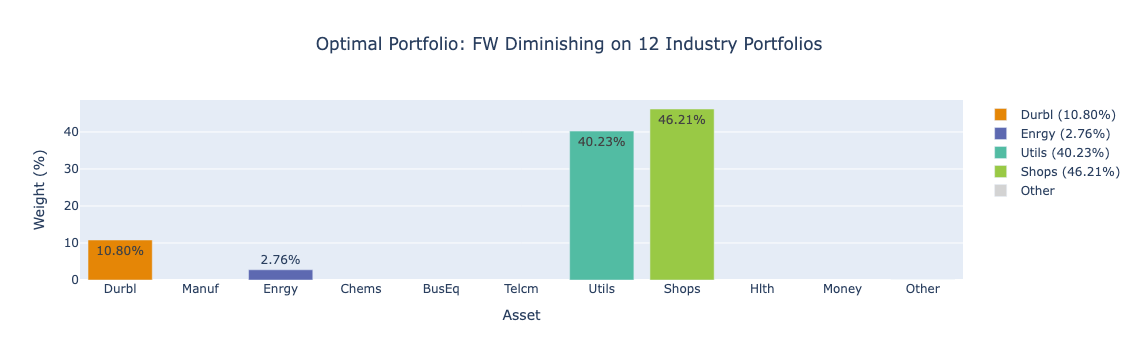

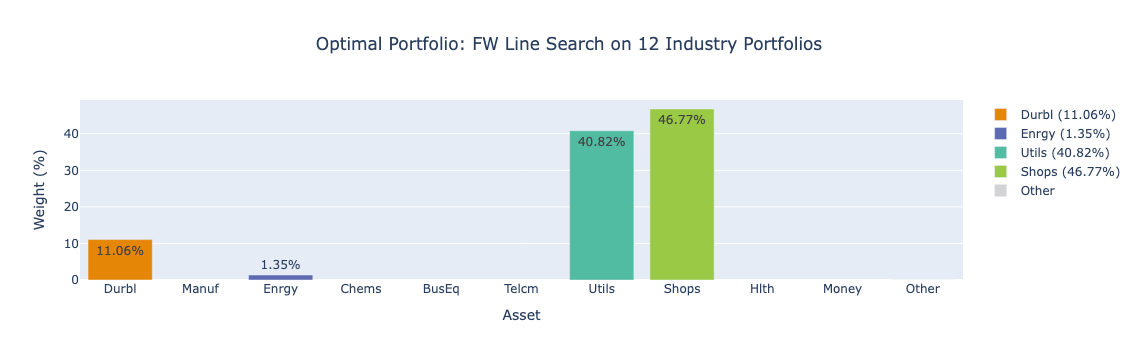

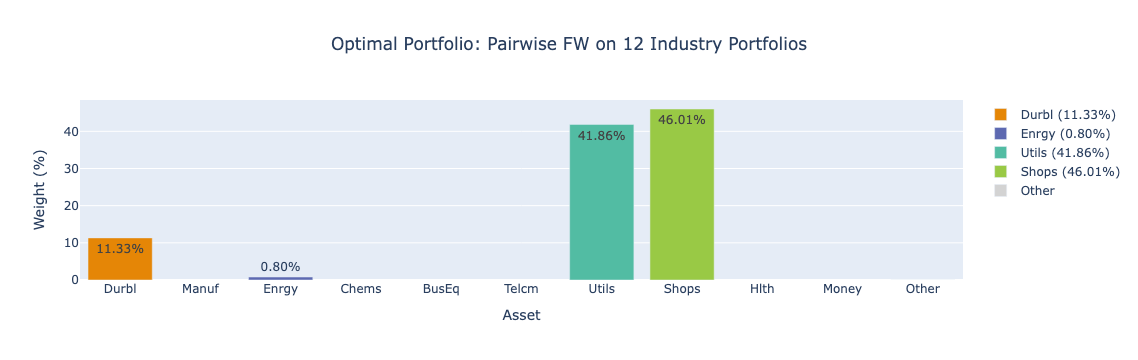

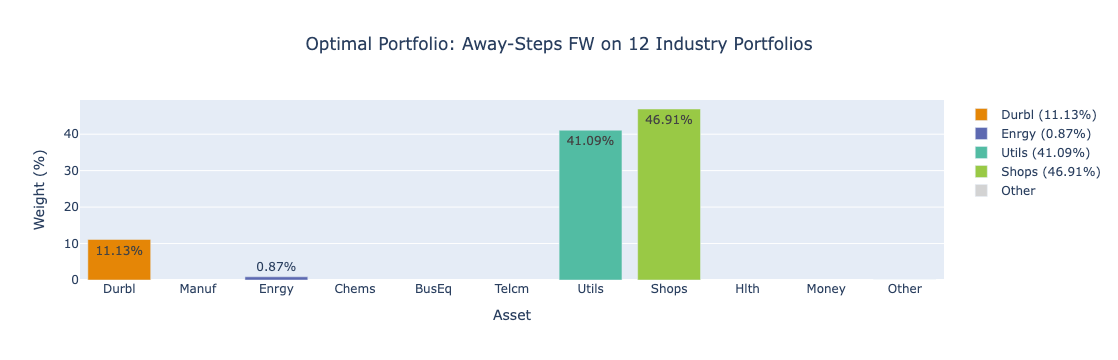


--- Portfolios for Dataset: 17 Portfolios ---


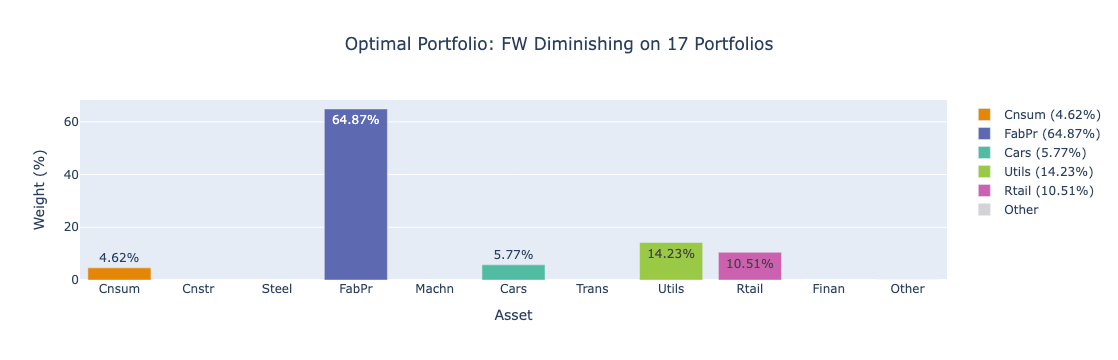

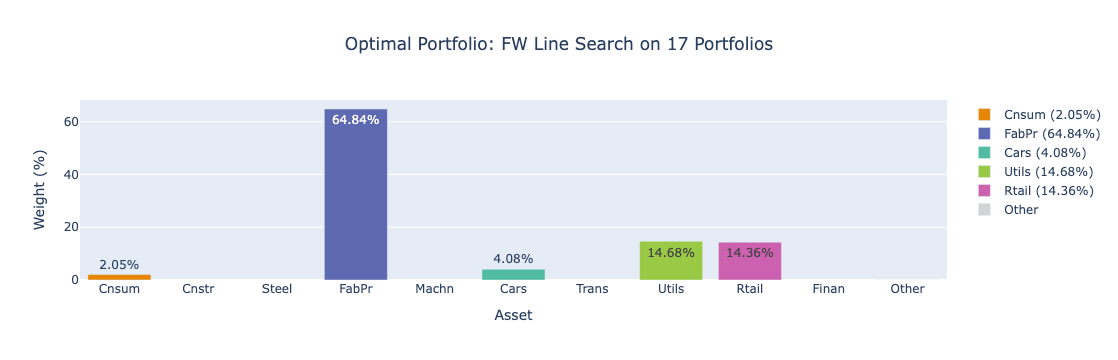

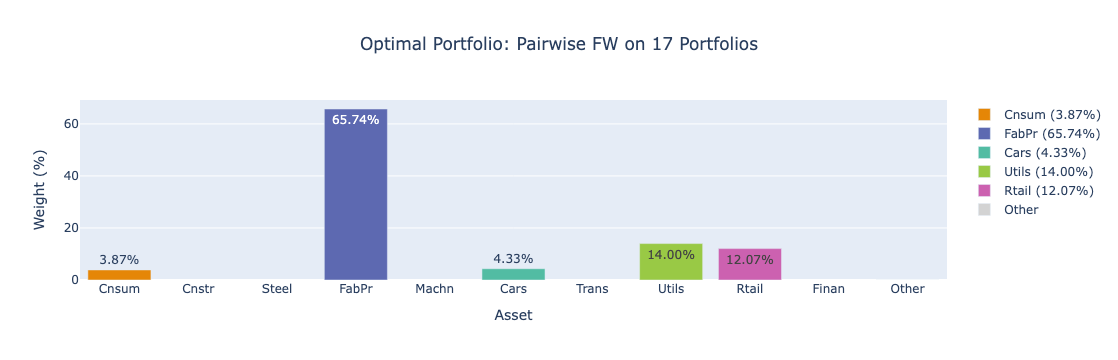

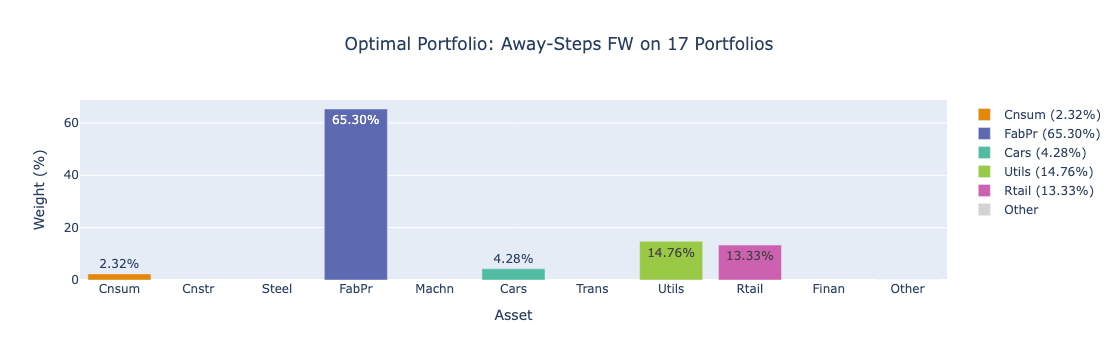


--- Portfolios for Dataset: 49 Industry Portfolios ---


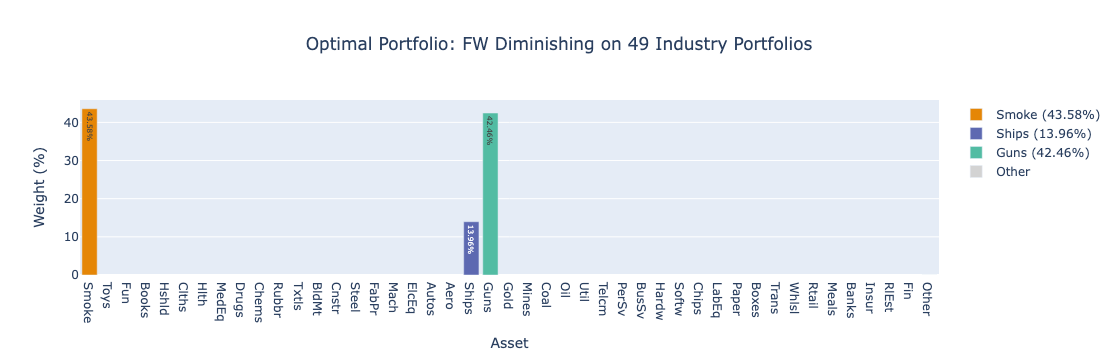

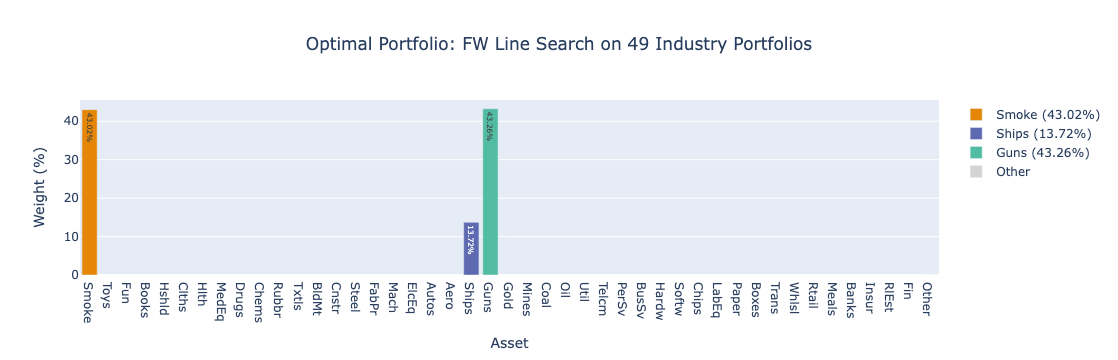

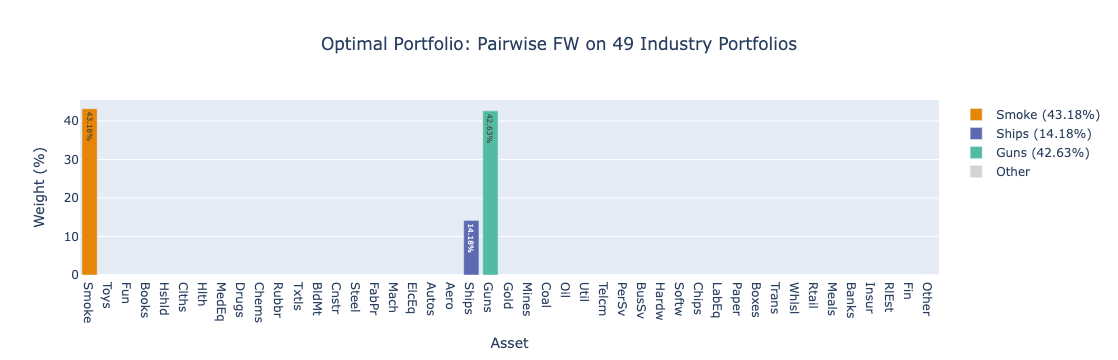

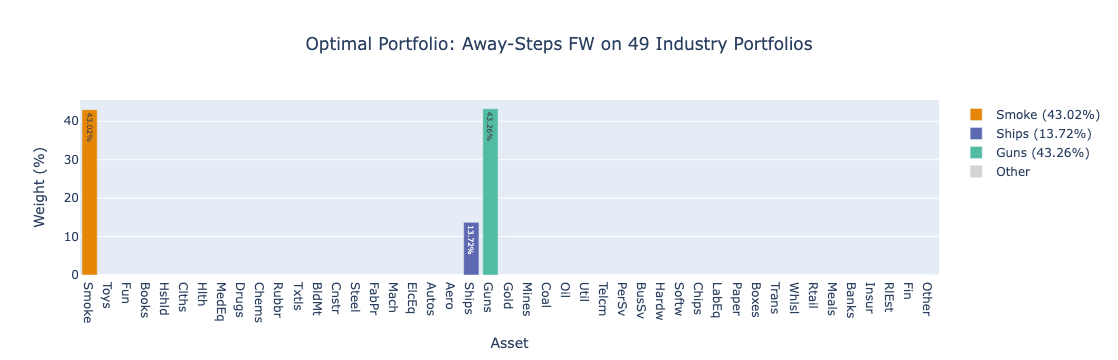

In [ ]:
#plot final portfolios
print("\n" + "="*80)
print("VISUALIZING ALL FINAL PORTFOLIOS")
print("="*80)

for dataset_name, data in all_results.items():
    print(f"\n--- Portfolios for Dataset: {dataset_name} ---")

    asset_labels = data['asset_names']

    for algo_name, run_data in data['runs'].items():
        portfolio_to_visualize = run_data['final_x']
        visualize_portfolio_bar(
            weights=portfolio_to_visualize,
            asset_names=asset_labels,
            chart_title=f"Optimal Portfolio: {algo_name} on {dataset_name}"
        )